In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("BankChurners.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,7.080821e+08,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,2.600000e+01,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,1.300000e+01,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1.438300e+03,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.000000e+00,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.000000e+00,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


In [35]:
leakage_cols = [c for c in df.columns if c.startswith("Naive_Bayes_Classifier")]
df = df.drop(columns=["CLIENTNUM"] + leakage_cols)

In [39]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f"\n")
    print(df[col].value_counts(dropna=False))



Gender
F    5358
M    4769
Name: count, dtype: int64


Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64


Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64


Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64


Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64


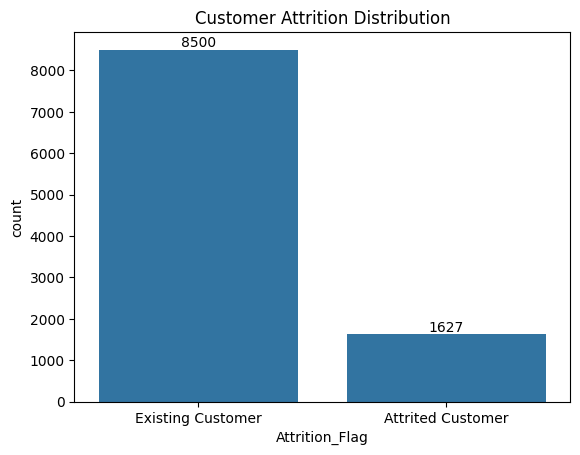

Attrition_Flag
Existing Customer    0.839
Attrited Customer    0.161
Name: proportion, dtype: float64


In [19]:
ax = sns.countplot(data=df, x="Attrition_Flag")
ax.set_title("Customer Attrition Distribution")
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

print(df["Attrition_Flag"].value_counts(normalize=True).round(3))

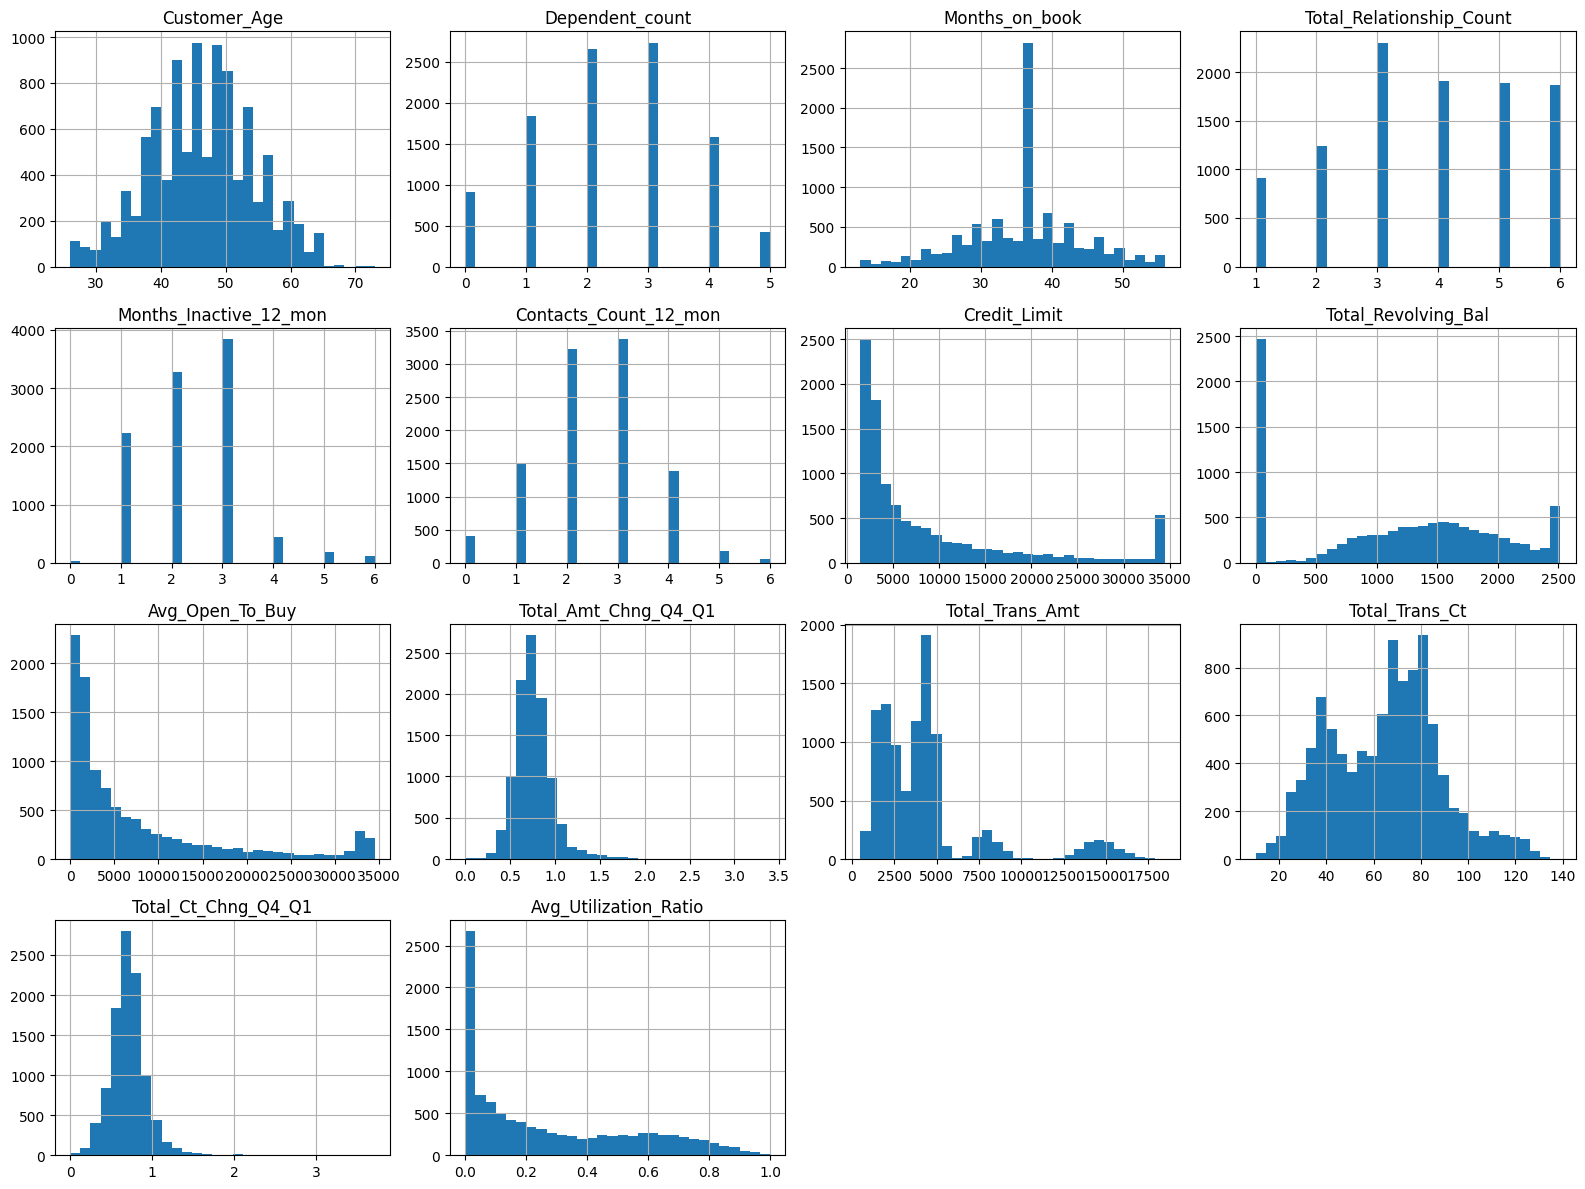

In [20]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

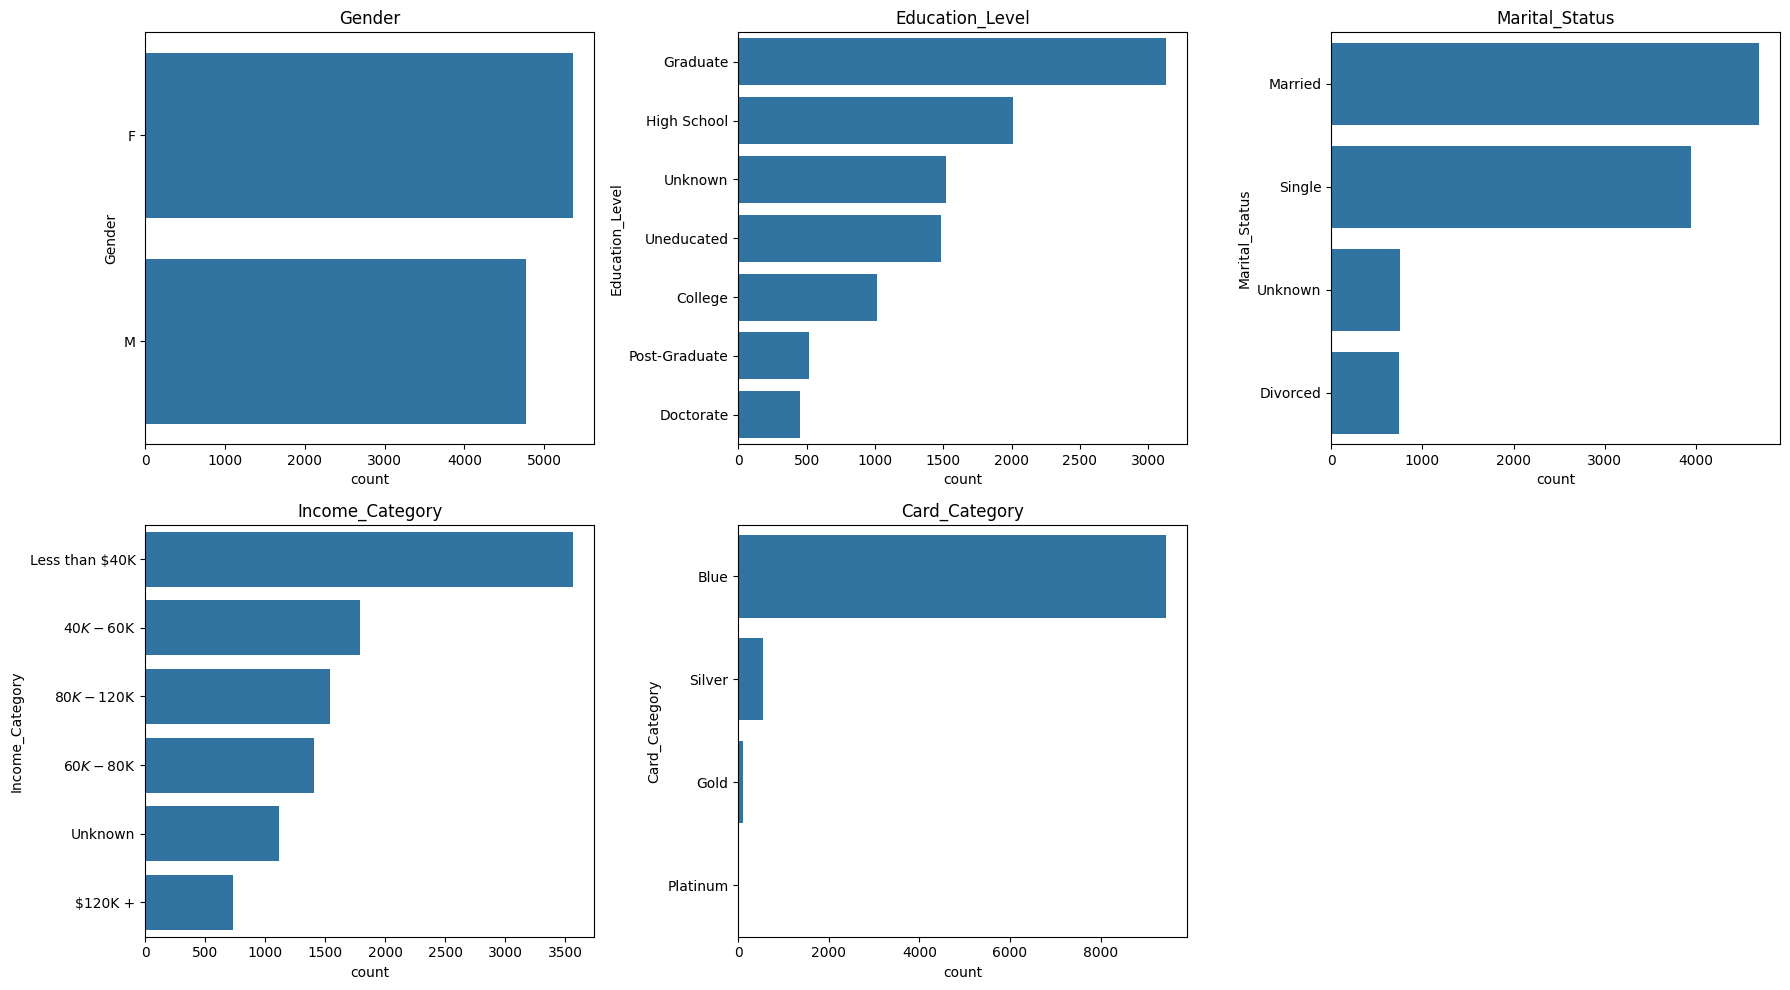

In [21]:
cat_features = ["Gender", "Education_Level", "Marital_Status",
                "Income_Category", "Card_Category"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), cat_features):
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

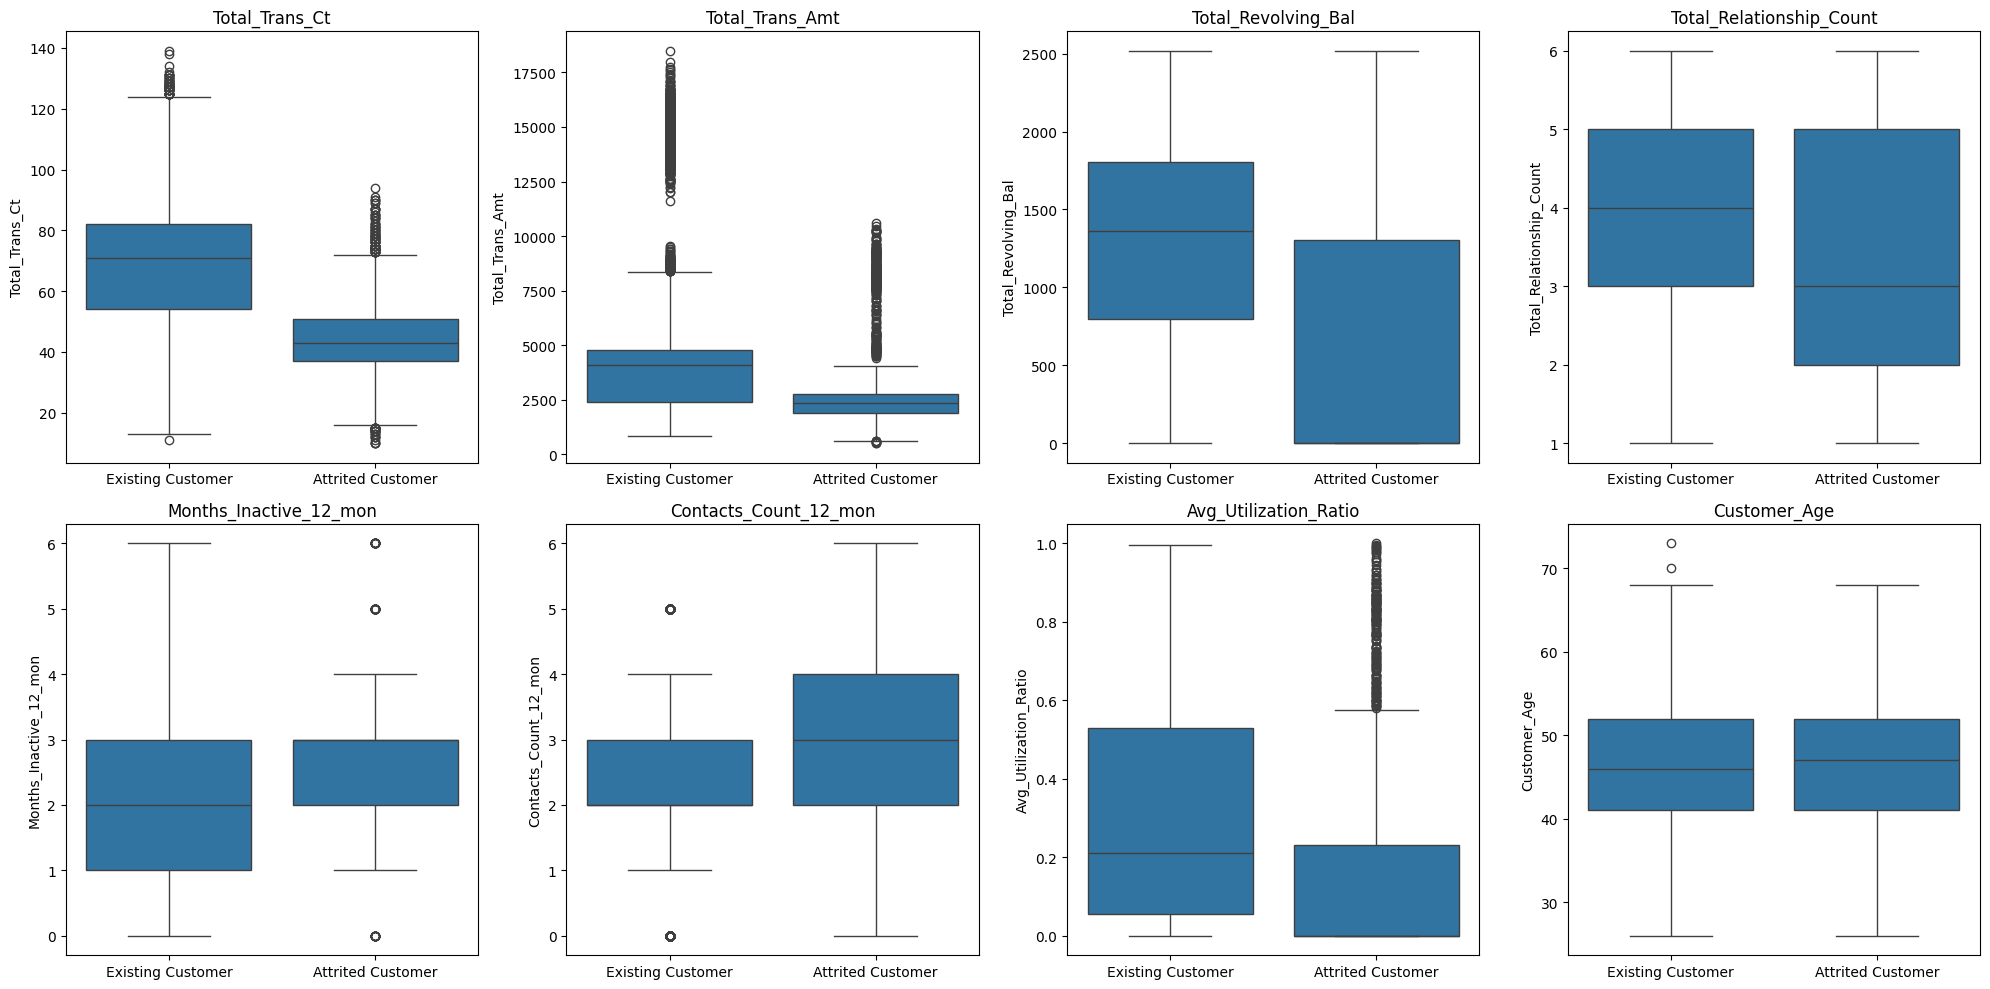

In [22]:
key_numeric = ["Total_Trans_Ct", "Total_Trans_Amt", "Total_Revolving_Bal",
               "Total_Relationship_Count", "Months_Inactive_12_mon",
               "Contacts_Count_12_mon", "Avg_Utilization_Ratio", "Customer_Age"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.ravel(), key_numeric):
    sns.boxplot(data=df, x="Attrition_Flag", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

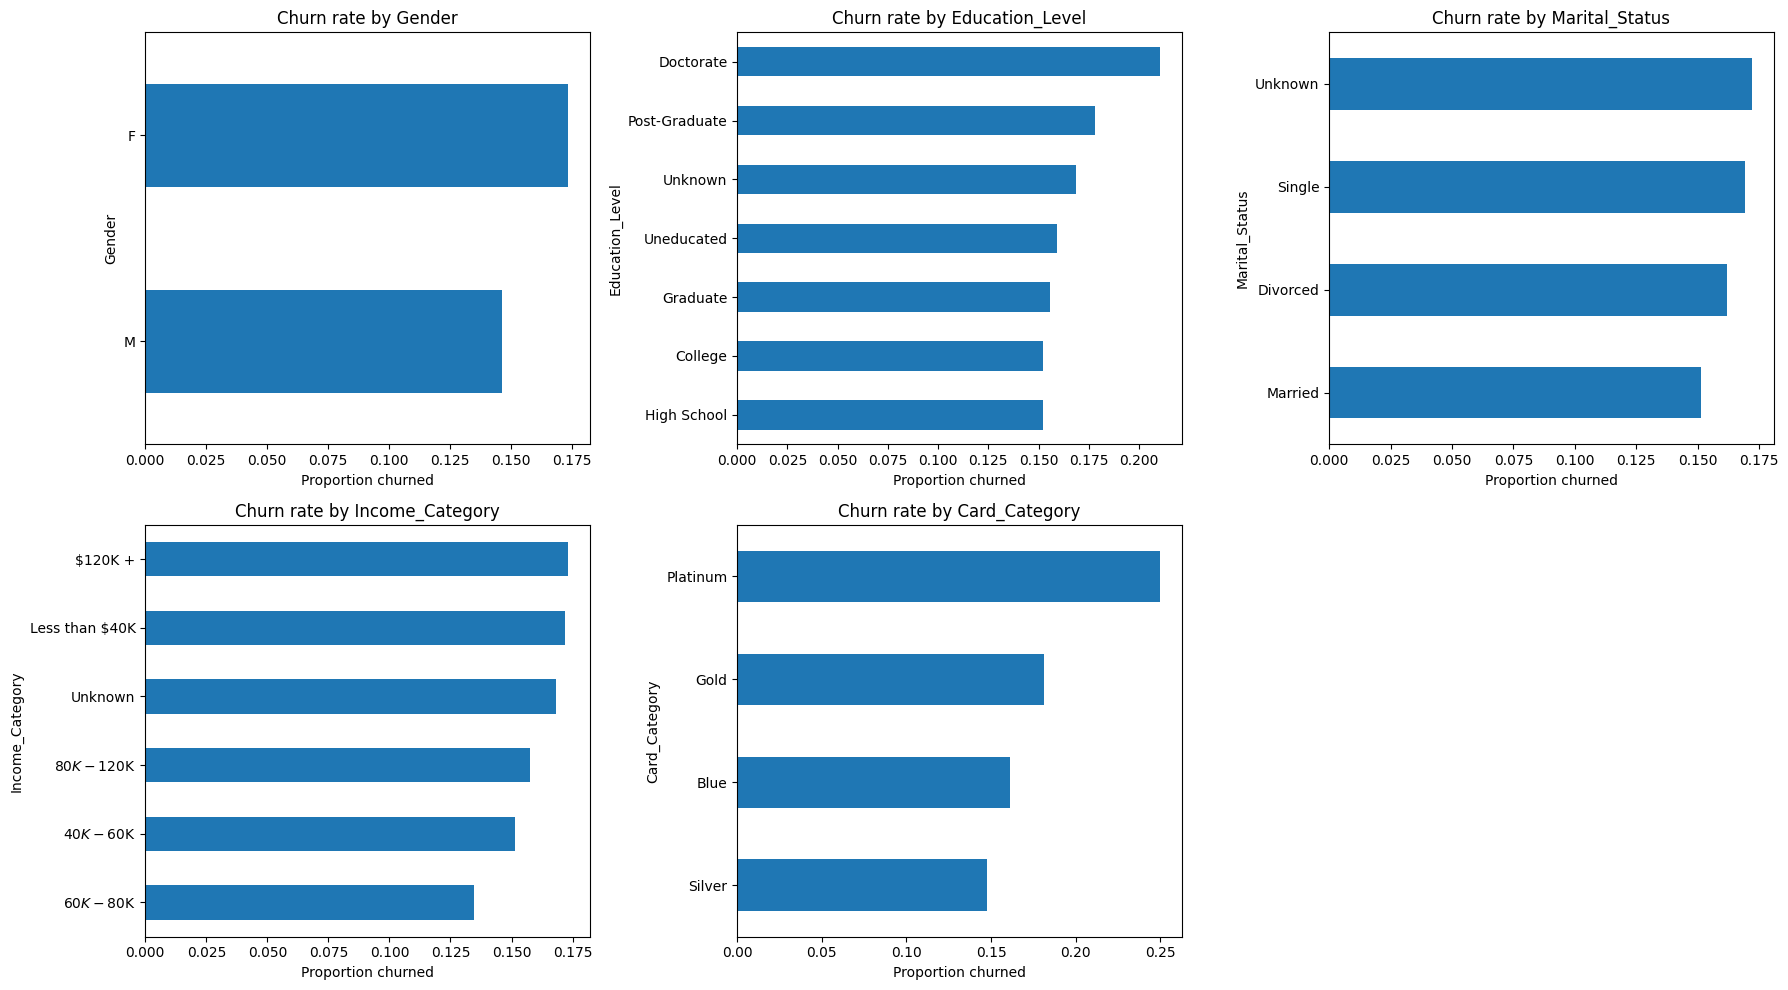

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), cat_features):
    # churn RATE within each category (normalized) is more informative than raw counts
    ctab = pd.crosstab(df[col], df["Attrition_Flag"], normalize="index")
    ctab["Attrited Customer"].sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Proportion churned")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

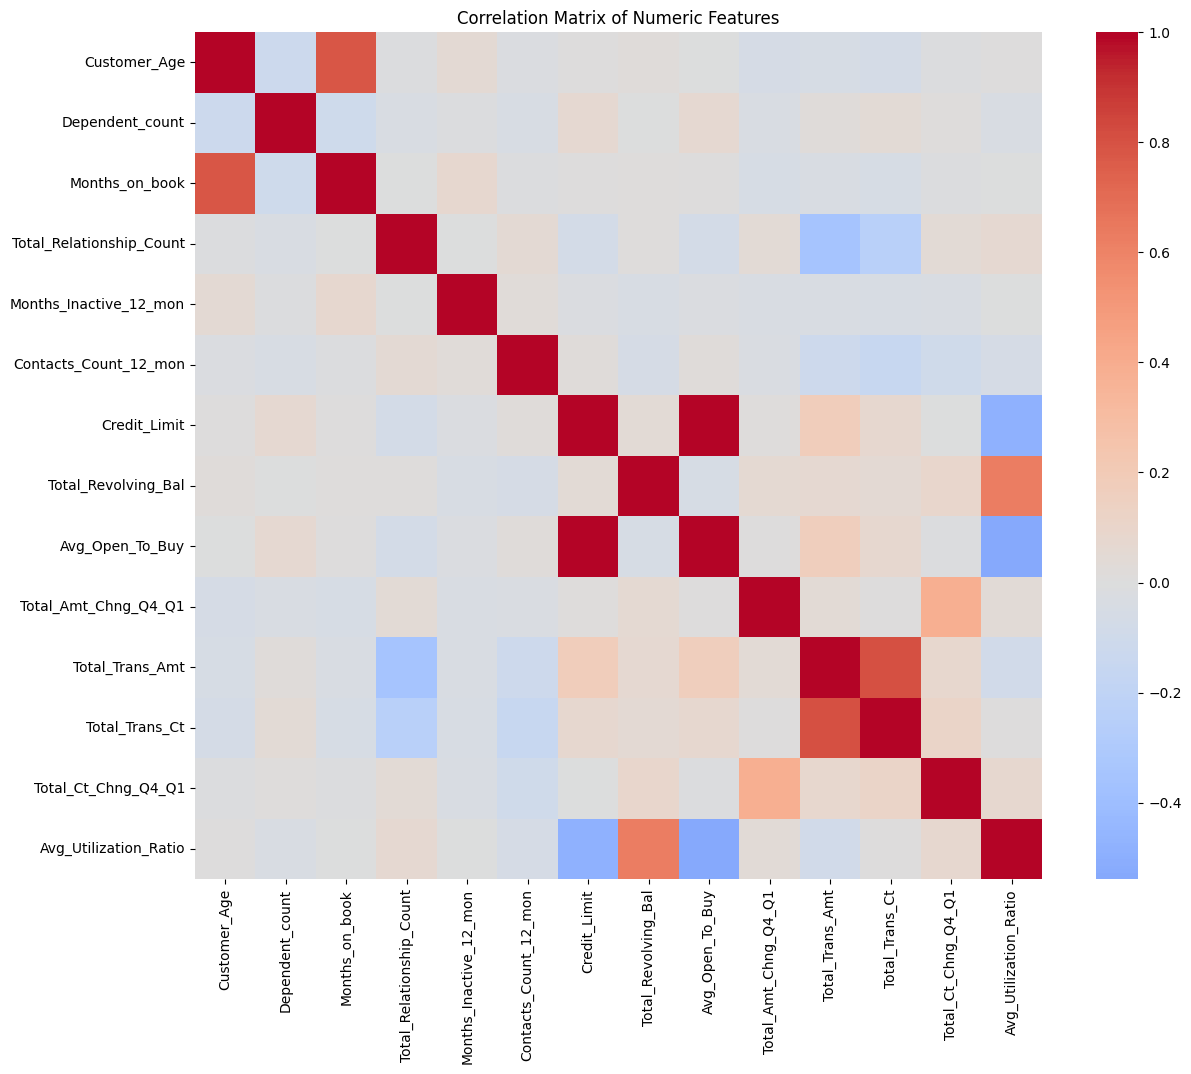

In [25]:
corr = df[num_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [27]:
df

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,target
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0
10123,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,1
10124,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,1
10125,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,1


In [36]:
# Target: binary 1 = churned, 0 = stayed
df["target"] = (df["Attrition_Flag"] == "Attrited Customer").astype(int)
df = df.drop(columns=["Attrition_Flag"])

In [40]:
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_model.drop(columns=["target"])
y = df_model["target"]

In [42]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [48]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced",
                            random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_lr  = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

In [50]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [52]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

In [53]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"\n========== {name} ==========")
    print(classification_report(y_true, y_pred, digits=3))
    print("ROC-AUC :", round(roc_auc_score(y_true, y_proba), 4))
    print("PR-AUC  :", round(average_precision_score(y_true, y_proba), 4))

evaluate("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
evaluate("Random Forest",       y_test, y_pred_rf, y_proba_rf)
evaluate("Gradient Boosting",   y_test, y_pred_gb, y_proba_gb)


========== Logistic Regression ==========
              precision    recall  f1-score   support

           0      0.961     0.862     0.909      1701
           1      0.531     0.818     0.644       325

    accuracy                          0.855      2026
   macro avg      0.746     0.840     0.776      2026
weighted avg      0.892     0.855     0.866      2026

ROC-AUC : 0.9207
PR-AUC  : 0.7314

========== Random Forest ==========
              precision    recall  f1-score   support

           0      0.951     0.990     0.970      1701
           1      0.933     0.732     0.821       325

    accuracy                          0.949      2026
   macro avg      0.942     0.861     0.895      2026
weighted avg      0.948     0.949     0.946      2026

ROC-AUC : 0.9855
PR-AUC  : 0.9392

========== Gradient Boosting ==========
              precision    recall  f1-score   support

           0      0.965     0.994     0.979      1701
           1      0.960     0.809     0.878     

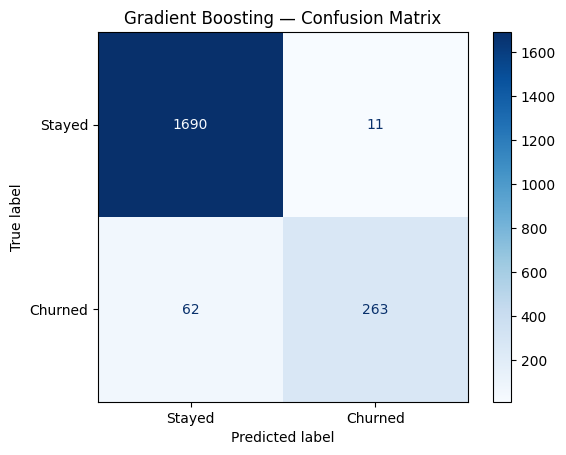

In [54]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_gb),
    display_labels=["Stayed", "Churned"]
).plot(cmap="Blues")
plt.title("Gradient Boosting — Confusion Matrix")
plt.show()

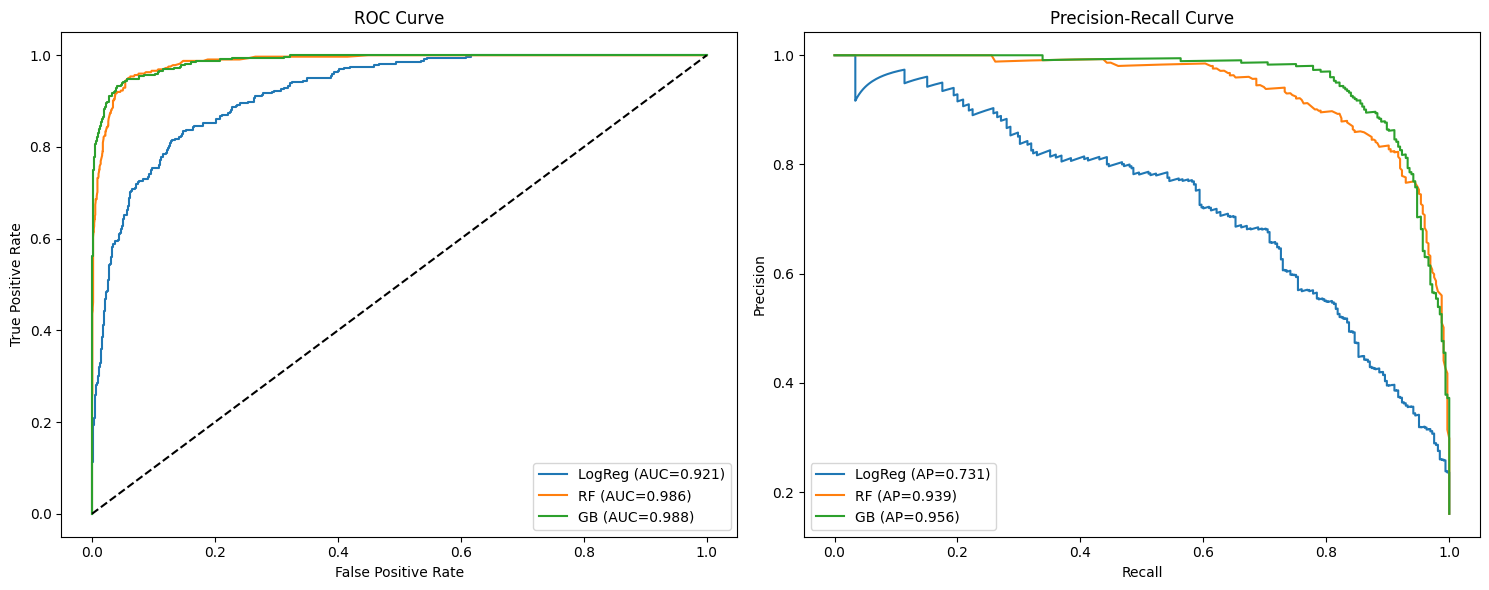

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, proba in [("LogReg", y_proba_lr), ("RF", y_proba_rf), ("GB", y_proba_gb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set(title="ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[0].legend()
axes[1].set(title="Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
axes[1].legend()
plt.tight_layout()
plt.show()

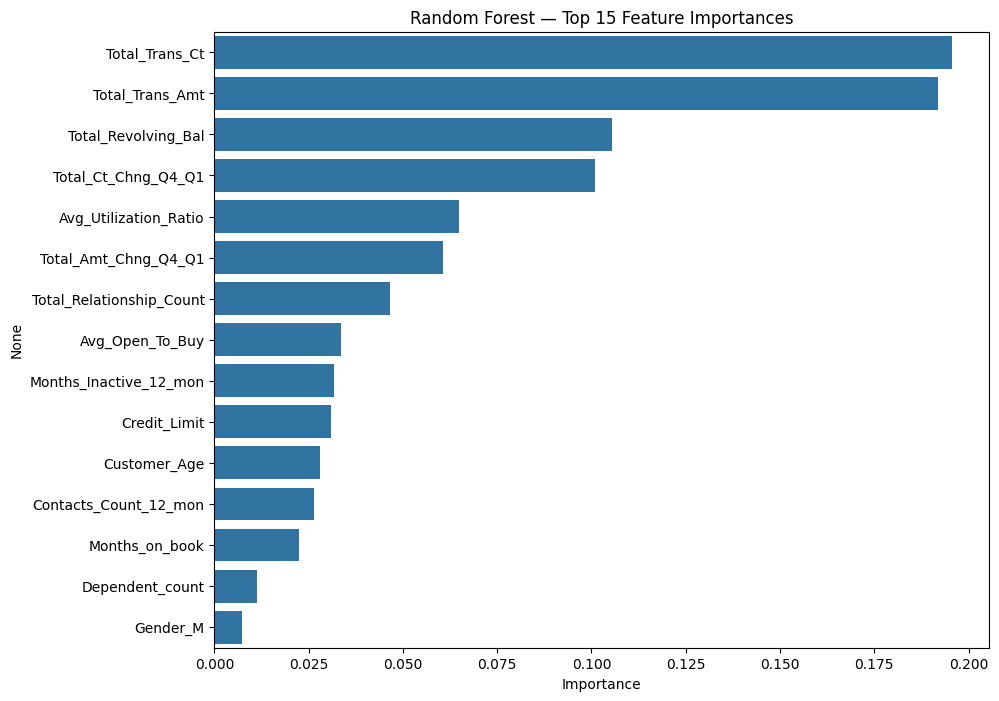

In [56]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top.values, y=top.index)
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()